In [1]:
import random
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# 1. Define the State
class State(TypedDict):
    number: int
    result_message: str

# 2. Define the Nodes
def generator_node(state: State):
    """Generates a random number."""
    num = random.randint(1, 100)
    print(f"--- GENERATED: {num} ---")
    return {"number": num}

def even_processor(state: State):
    """Logic specifically for even numbers."""
    return {"result_message": f"You entered {state['number']}, it is even."}

def odd_processor(state: State):
    """Logic specifically for odd numbers."""
    return {"result_message": f"You entered {state['number']}, it is odd."}

# 3. Define the Routing Logic
def route_decision(state: State) -> Literal["even_path", "odd_path"]:
    """Determines which node to visit next."""
    if state["number"] % 2 == 0:
        return "even_path"
    return "odd_path"

# 4. Build the Graph
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("generator", generator_node)
workflow.add_node("even_node", even_processor)
workflow.add_node("odd_node", odd_processor)

# Define Edges
workflow.add_edge(START, "generator")

# Add Conditional Edges
# Arguments: (Source Node, Routing Function, Mapping of function output to Node names)
workflow.add_conditional_edges(
    "generator",
    route_decision,
    {
        "even_path": "even_node",
        "odd_path": "odd_node"
    }
)

# Connect branch ends to the END
workflow.add_edge("even_node", END)
workflow.add_edge("odd_node", END)

# Compile and Run
app = workflow.compile() 


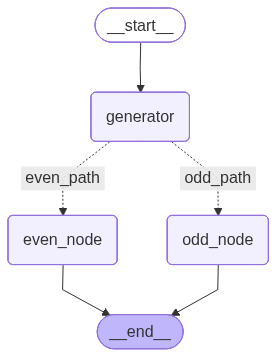

In [2]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [3]:
from mermaid import Mermaid

mermaid_str = app.get_graph().draw_mermaid()
Mermaid(mermaid_str)

In [4]:
final_output = app.invoke({"number": 0, "result_message": ""})

print(f"FINAL RESULT: {final_output['result_message']}")

--- GENERATED: 31 ---
FINAL RESULT: You entered 31, it is odd.
